In [1]:
'''
- Import thư viện cần dùng
- Setup environment chạy notebook
'''
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)


def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()

    for p in [start, *start.parents]:
        if (p / "README.md").exists() and (p / "data").exists() and (p / "src").exists():
            return p

    raise FileNotFoundError("Khong tim thay project root.")


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

try:
    from src.config import REPORTS_DIR
except Exception:
    REPORTS_DIR = PROJECT_ROOT / "reports"

OUTPUT_DIR = REPORTS_DIR / "data_audit"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR}")

PROJECT_ROOT: /home/habi/study/hau/university/DATATHON2026
OUTPUT_DIR   : /home/habi/study/hau/university/DATATHON2026/reports/data_audit


In [2]:
'''
- Load toàn bộ data bằng src/data_loader.py
'''

from src.data_loader import load_all_data

tables = load_all_data()

expected_tables = [
    "products",
    "customers",
    "promotions",
    "geography",
    "orders",
    "order_items",
    "payments",
    "shipments",
    "returns",
    "reviews",
    "inventory",
    "web_traffic",
    "sales",
    "sample_submission",
]

missing_tables = [name for name in expected_tables if name not in tables]
extra_tables = [name for name in tables.keys() if name not in expected_tables]

print("Loaded tables:", sorted(tables.keys()))
print("Missing tables:", missing_tables)
print("Extra tables  :", extra_tables)

if missing_tables:
    raise ValueError(f"Thieu table trong load_all_data(): {missing_tables}")

for name in expected_tables:
    globals()[name] = tables[name]

inventory_loaded = pd.DataFrame({
    "table": expected_tables,
    "rows": [tables[name].shape[0] for name in expected_tables],
    "cols": [tables[name].shape[1] for name in expected_tables],
    "memory_mb": [round(tables[name].memory_usage(deep=True).sum() / 1024**2, 2) for name in expected_tables],
})

display(inventory_loaded)
inventory_loaded.to_csv(OUTPUT_DIR / "inventory_summary.csv", index=False)

Loaded tables: ['customers', 'geography', 'inventory', 'order_items', 'orders', 'payments', 'products', 'promotions', 'returns', 'reviews', 'sales', 'sample_submission', 'shipments', 'web_traffic']
Missing tables: []
Extra tables  : []


,table,rows,cols,memory_mb
0,products,2412,8,0.71
1,customers,121930,7,29.05
2,promotions,50,10,0.02
3,geography,39948,4,6.86
4,orders,646945,8,162.78
5,order_items,714669,7,78.00
6,payments,646945,4,50.56
7,shipments,566067,4,17.28
8,returns,39939,7,6.08
9,reviews,113551,7,17.76


## Helper functions
- schema profiling
- null profiling
- duplicates
- candidate key check
- foreign key / join coverage
- export summary

In [3]:
# profile schema
def profile_table(table_name: str, df: pd.DataFrame) -> pd.DataFrame:
    rows, cols = df.shape
    records = []

    for col in df.columns:
        s = df[col]
        sample_values = s.dropna().astype(str).head(3).tolist()

        records.append({
            "table": table_name,
            "n_rows": rows,
            "n_cols": cols,
            "column": col,
            "dtype": str(s.dtype),
            "null_count": int(s.isna().sum()),
            "null_pct": round(float(s.isna().mean() * 100), 4),
            "nunique": int(s.nunique(dropna=True)),
            "is_unique_non_null": bool(s.notna().all() and s.is_unique),
            "sample_values": " | ".join(sample_values),
        })

    return pd.DataFrame(records)

# check duplicate
def duplicate_stats(table_name: str, df: pd.DataFrame, subset=None, label=None) -> dict:
    if subset is None:
        dup_count = int(df.duplicated().sum())
        subset_name = "FULL_ROW"
    else:
        dup_count = int(df.duplicated(subset=subset).sum())
        subset_name = ", ".join(subset)

    return {
        "table": table_name,
        "check_type": label if label else "duplicate_check",
        "subset": subset_name,
        "duplicate_count": dup_count,
        "duplicate_pct": round(dup_count / len(df) * 100, 6) if len(df) else 0.0,
    }

# check key
def candidate_key_check(table_name: str, df: pd.DataFrame, key_cols, note=None) -> dict:
    if isinstance(key_cols, str):
        key_cols = [key_cols]

    null_rows = int(df[key_cols].isna().any(axis=1).sum())
    dup_rows = int(df.duplicated(subset=key_cols).sum())

    return {
        "table": table_name,
        "key_cols": ", ".join(key_cols),
        "rows": int(len(df)),
        "null_rows_in_key": null_rows,
        "duplicate_rows_on_key": dup_rows,
        "is_valid_candidate_key": bool(null_rows == 0 and dup_rows == 0),
        "note": note if note else "",
    }

# check join / fk
def fk_coverage_check(
    child_table_name: str,
    child_df: pd.DataFrame,
    child_col: str,
    parent_table_name: str,
    parent_df: pd.DataFrame,
    parent_col: str,
    allow_null: bool = False,
    relationship_note: str = ""
) -> dict:
    child_series = child_df[child_col]
    parent_values = set(parent_df[parent_col].dropna().unique())

    not_null_mask = child_series.notna()
    unmatched_mask = not_null_mask & ~child_series.isin(parent_values)

    total_rows = int(len(child_df))
    not_null_rows = int(not_null_mask.sum())
    unmatched_rows = int(unmatched_mask.sum())

    return {
        "child_table": child_table_name,
        "child_col": child_col,
        "parent_table": parent_table_name,
        "parent_col": parent_col,
        "allow_null": allow_null,
        "total_rows": total_rows,
        "not_null_rows": not_null_rows,
        "unmatched_rows": unmatched_rows,
        "unmatched_pct_over_not_null": round(unmatched_rows / not_null_rows * 100, 6) if not_null_rows else 0.0,
        "relationship_note": relationship_note,
    }

# export kq
def save_df(df: pd.DataFrame, filename: str):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved: {path}")

## 1. Data inventory
Mục tiêu:
- nhìn nhanh tất cả bảng
- số dòng / số cột / memory usage
- xác nhận đã load đủ dữ liệu

In [4]:
inventory_summary = pd.DataFrame({
    "table": expected_tables,
    "rows": [tables[name].shape[0] for name in expected_tables],
    "cols": [tables[name].shape[1] for name in expected_tables],
    "memory_mb": [round(tables[name].memory_usage(deep=True).sum() / 1024**2, 2) for name in expected_tables],
})

display(inventory_summary.sort_values("rows", ascending=False))
save_df(inventory_summary, "inventory_summary.csv")

,table,rows,cols,memory_mb
5,order_items,714669,7,78.00
4,orders,646945,8,162.78
6,payments,646945,4,50.56
7,shipments,566067,4,17.28
1,customers,121930,7,29.05
9,reviews,113551,7,17.76
10,inventory,60247,17,16.76
3,geography,39948,4,6.86
8,returns,39939,7,6.08
12,sales,3833,3,0.09


Saved: /home/habi/study/hau/university/DATATHON2026/reports/data_audit/inventory_summary.csv


## 2. Schema audit
Mục tiêu:
- tên cột
- kiểu dữ liệu
- số lượng null
- số lượng distinct
- kiểm tra uniqueness cơ bản

In [5]:
schema_summary = pd.concat(
    [profile_table(name, tables[name]) for name in expected_tables],
    ignore_index=True
).sort_values(["table", "column"]).reset_index(drop=True)

display(schema_summary.head(100))
save_df(schema_summary, "schema_summary.csv")

,table,n_rows,n_cols,column,dtype,null_count,null_pct,nunique,is_unique_non_null,sample_values
0,customers,121930,7,acquisition_channel,str,0,0.0,6,False,social_media | email_campaign | organic_search
1,customers,121930,7,age_group,str,0,0.0,5,False,35-44 | 45-54 | 18-24
2,customers,121930,7,city,str,0,0.0,42,False,Hai Phong | Hai Phong | Hai Phong
3,customers,121930,7,customer_id,int64,0,0.0,121930,True,1 | 2 | 3
4,customers,121930,7,gender,str,0,0.0,3,False,Female | Female | Female
...,...,...,...,...,...,...,...,...,...,...
91,web_traffic,3652,7,date,datetime64[us],0,0.0,3652,True,2013-01-01 | 2013-01-02 | 2013-01-03
92,web_traffic,3652,7,page_views,int64,0,0.0,3620,False,39093 | 47611 | 36963
93,web_traffic,3652,7,sessions,int64,0,0.0,3447,False,9760 | 10456 | 10076
94,web_traffic,3652,7,traffic_source,str,0,0.0,6,False,organic_search | organic_search | direct


Saved: /home/habi/study/hau/university/DATATHON2026/reports/data_audit/schema_summary.csv


## 3. Null audit
Ở phase này chỉ **report null**, chưa xử lý fillna/drop hàng loạt.

In [6]:
null_summary = (
    schema_summary.loc[:, ["table", "column", "dtype", "null_count", "null_pct"]]
    .sort_values(["null_pct", "null_count"], ascending=[False, False])
    .reset_index(drop=True)
)

display(null_summary.query("null_count > 0").head(100))
save_df(null_summary, "null_summary.csv")

,table,column,dtype,null_count,null_pct
0,order_items,promo_id_2,str,714463,99.9712
1,promotions,applicable_category,str,40,80.0000
2,order_items,promo_id,str,438353,61.3365


Saved: /home/habi/study/hau/university/DATATHON2026/reports/data_audit/null_summary.csv


## 4. Duplicate audit
Phân biệt:
- full-row duplicate
- duplicate theo candidate key
- duplicate theo business key phụ (nếu cần)

In [7]:
duplicate_records = []

for name in expected_tables:
    duplicate_records.append(duplicate_stats(name, tables[name], subset=None, label="full_row_duplicate"))

# Một vài business-key duplicate check hữu ích
duplicate_records.append(
    duplicate_stats("order_items", order_items, subset=["order_id", "product_id"], label="business_key_duplicate")
)
duplicate_records.append(
    duplicate_stats("inventory", inventory, subset=["snapshot_date", "product_id"], label="business_key_duplicate")
)

duplicate_summary = pd.DataFrame(duplicate_records).sort_values(
    ["duplicate_count", "table"], ascending=[False, True]
).reset_index(drop=True)

display(duplicate_summary)
save_df(duplicate_summary, "duplicate_summary.csv")

,table,check_type,subset,duplicate_count,duplicate_pct
0,order_items,business_key_duplicate,"order_id, product_id",16,0.002239
1,customers,full_row_duplicate,FULL_ROW,0,0.000000
2,geography,full_row_duplicate,FULL_ROW,0,0.000000
3,inventory,full_row_duplicate,FULL_ROW,0,0.000000
4,inventory,business_key_duplicate,"snapshot_date, product_id",0,0.000000
5,order_items,full_row_duplicate,FULL_ROW,0,0.000000
6,orders,full_row_duplicate,FULL_ROW,0,0.000000
7,payments,full_row_duplicate,FULL_ROW,0,0.000000
8,products,full_row_duplicate,FULL_ROW,0,0.000000
9,promotions,full_row_duplicate,FULL_ROW,0,0.000000


Saved: /home/habi/study/hau/university/DATATHON2026/reports/data_audit/duplicate_summary.csv


## 5. Candidate key audit
Kiểm tra các key quan trọng theo mô tả đề và logic dữ liệu.

In [ ]:
candidate_key_records = [
    candidate_key_check("products", products, "product_id"),
    candidate_key_check("customers", customers, "customer_id"),
    candidate_key_check("promotions", promotions, "promo_id"),
    candidate_key_check("geography", geography, "zip"),
    candidate_key_check("orders", orders, "order_id"),
    candidate_key_check("payments", payments, "order_id", note="Expected 1:1 with orders"),
    candidate_key_check("shipments", shipments, "order_id", note="Expected 0/1 shipment per order"),
    candidate_key_check("returns", returns, "return_id"),
    candidate_key_check("reviews", reviews, "review_id"),
    candidate_key_check("inventory", inventory, ["snapshot_date", "product_id"], note="1 row per product per month snapshot"),
    candidate_key_check("sales", sales, "Date"),
    candidate_key_check("sample_submission", sample_submission, "Date"),
]

candidate_key_summary = pd.DataFrame(candidate_key_records)
display(candidate_key_summary)
save_df(candidate_key_summary, "candidate_key_summary.csv")

## 6. Foreign key / join coverage audit
Mục tiêu:
- xem join có bị orphan records không (foreign key hỏng)
- xác nhận các quan hệ chính có khớp với đề không

In [8]:
join_records = [
    fk_coverage_check("customers", customers, "zip", "geography", geography, "zip", allow_null=False, relationship_note="customers.zip -> geography.zip"),
    fk_coverage_check("orders", orders, "customer_id", "customers", customers, "customer_id", allow_null=False, relationship_note="orders.customer_id -> customers.customer_id"),
    fk_coverage_check("orders", orders, "zip", "geography", geography, "zip", allow_null=False, relationship_note="orders.zip -> geography.zip"),
    fk_coverage_check("order_items", order_items, "order_id", "orders", orders, "order_id", allow_null=False, relationship_note="order_items.order_id -> orders.order_id"),
    fk_coverage_check("order_items", order_items, "product_id", "products", products, "product_id", allow_null=False, relationship_note="order_items.product_id -> products.product_id"),
    fk_coverage_check("order_items", order_items, "promo_id", "promotions", promotions, "promo_id", allow_null=True, relationship_note="order_items.promo_id -> promotions.promo_id"),
    fk_coverage_check("order_items", order_items, "promo_id_2", "promotions", promotions, "promo_id", allow_null=True, relationship_note="order_items.promo_id_2 -> promotions.promo_id"),
    fk_coverage_check("payments", payments, "order_id", "orders", orders, "order_id", allow_null=False, relationship_note="payments.order_id -> orders.order_id"),
    fk_coverage_check("shipments", shipments, "order_id", "orders", orders, "order_id", allow_null=False, relationship_note="shipments.order_id -> orders.order_id"),
    fk_coverage_check("returns", returns, "order_id", "orders", orders, "order_id", allow_null=False, relationship_note="returns.order_id -> orders.order_id"),
    fk_coverage_check("returns", returns, "product_id", "products", products, "product_id", allow_null=False, relationship_note="returns.product_id -> products.product_id"),
    fk_coverage_check("reviews", reviews, "order_id", "orders", orders, "order_id", allow_null=False, relationship_note="reviews.order_id -> orders.order_id"),
    fk_coverage_check("reviews", reviews, "product_id", "products", products, "product_id", allow_null=False, relationship_note="reviews.product_id -> products.product_id"),
    fk_coverage_check("reviews", reviews, "customer_id", "customers", customers, "customer_id", allow_null=False, relationship_note="reviews.customer_id -> customers.customer_id"),
    fk_coverage_check("inventory", inventory, "product_id", "products", products, "product_id", allow_null=False, relationship_note="inventory.product_id -> products.product_id"),
]

join_check_summary = pd.DataFrame(join_records).sort_values(
    ["unmatched_rows", "child_table"], ascending=[False, True]
).reset_index(drop=True)

display(join_check_summary)
save_df(join_check_summary, "join_check_summary.csv")

,child_table,child_col,parent_table,parent_col,allow_null,total_rows,not_null_rows,unmatched_rows,unmatched_pct_over_not_null,relationship_note
0,customers,zip,geography,zip,False,121930,121930,0,0.0,customers.zip -> geography.zip
1,inventory,product_id,products,product_id,False,60247,60247,0,0.0,inventory.product_id -> products.product_id
2,order_items,order_id,orders,order_id,False,714669,714669,0,0.0,order_items.order_id -> orders.order_id
3,order_items,product_id,products,product_id,False,714669,714669,0,0.0,order_items.product_id -> products.product_id
4,order_items,promo_id,promotions,promo_id,True,714669,276316,0,0.0,order_items.promo_id -> promotions.promo_id
5,order_items,promo_id_2,promotions,promo_id,True,714669,206,0,0.0,order_items.promo_id_2 -> promotions.promo_id
6,orders,customer_id,customers,customer_id,False,646945,646945,0,0.0,orders.customer_id -> customers.customer_id
7,orders,zip,geography,zip,False,646945,646945,0,0.0,orders.zip -> geography.zip
8,payments,order_id,orders,order_id,False,646945,646945,0,0.0,payments.order_id -> orders.order_id
9,returns,order_id,orders,order_id,False,39939,39939,0,0.0,returns.order_id -> orders.order_id


Saved: /home/habi/study/hau/university/DATATHON2026/reports/data_audit/join_check_summary.csv


## 7. Business rule audit
Kiểm tra một số rule cơ bản từ đề và logic nghiệp vụ:
- cogs < price
- promotions start_date <= end_date
- shipments chỉ xuất hiện cho các order status phù hợp
- reviews rating trong [1, 5]
- flags là nhị phân
- payment method giữa orders và payments có khớp không

In [9]:
business_rules = []

# 1) products: cogs < price
viol_products_margin = int((products["cogs"] >= products["price"]).sum())
business_rules.append({
    "rule_name": "products_cogs_less_than_price",
    "violations": viol_products_margin,
    "status": "PASS" if viol_products_margin == 0 else "FAIL",
    "details": "Expected cogs < price for all products"
})

# 2) promotions: start_date <= end_date
viol_promo_dates = int((promotions["start_date"] > promotions["end_date"]).sum())
business_rules.append({
    "rule_name": "promotions_start_before_end",
    "violations": viol_promo_dates,
    "status": "PASS" if viol_promo_dates == 0 else "FAIL",
    "details": "Expected promotions.start_date <= promotions.end_date"
})

# 3) shipments: ship_date <= delivery_date
viol_shipment_dates = int((shipments["ship_date"] > shipments["delivery_date"]).sum())
business_rules.append({
    "rule_name": "shipments_ship_before_delivery",
    "violations": viol_shipment_dates,
    "status": "PASS" if viol_shipment_dates == 0 else "FAIL",
    "details": "Expected ship_date <= delivery_date"
})

# 4) reviews: rating in [1, 5]
viol_review_rating = int((~reviews["rating"].between(1, 5, inclusive="both")).sum())
business_rules.append({
    "rule_name": "reviews_rating_between_1_and_5",
    "violations": viol_review_rating,
    "status": "PASS" if viol_review_rating == 0 else "FAIL",
    "details": "Expected rating between 1 and 5"
})

# 5) inventory flags are binary
for flag_col in ["stockout_flag", "overstock_flag", "reorder_flag"]:
    if flag_col in inventory.columns:
        valid_mask = inventory[flag_col].isin([0, 1])
        violations = int((~valid_mask).sum())
        business_rules.append({
            "rule_name": f"inventory_{flag_col}_binary",
            "violations": violations,
            "status": "PASS" if violations == 0 else "FAIL",
            "details": f"Expected {flag_col} in {{0,1}}"
        })

# 6) orders vs payments payment_method consistency
orders_payments = orders.merge(
    payments[["order_id", "payment_method"]],
    on="order_id",
    how="inner",
    suffixes=("_orders", "_payments")
)

payment_method_mismatch = int(
    (orders_payments["payment_method_orders"] != orders_payments["payment_method_payments"]).sum()
)

business_rules.append({
    "rule_name": "orders_payments_payment_method_consistency",
    "violations": payment_method_mismatch,
    "status": "PASS" if payment_method_mismatch == 0 else "WARN",
    "details": "Expected payment_method in orders and payments to match"
})

# 7) shipments should belong to shipped / delivered / returned orders
valid_shipment_status = {"shipped", "delivered", "returned"}
shipments_orders = shipments.merge(
    orders[["order_id", "order_status"]],
    on="order_id",
    how="left"
)
viol_shipment_status = int((~shipments_orders["order_status"].isin(valid_shipment_status)).sum())

business_rules.append({
    "rule_name": "shipments_order_status_valid",
    "violations": viol_shipment_status,
    "status": "PASS" if viol_shipment_status == 0 else "WARN",
    "details": "Expected shipments only for shipped/delivered/returned orders"
})

# 8) returns should belong to returned orders
returns_orders = returns.merge(
    orders[["order_id", "order_status"]],
    on="order_id",
    how="left"
)
viol_return_status = int((returns_orders["order_status"] != "returned").sum())

business_rules.append({
    "rule_name": "returns_order_status_returned",
    "violations": viol_return_status,
    "status": "PASS" if viol_return_status == 0 else "WARN",
    "details": "Expected returns to belong to orders with status='returned'"
})

# 9) reviews ideally on delivered orders
reviews_orders = reviews.merge(
    orders[["order_id", "order_status"]],
    on="order_id",
    how="left"
)
viol_review_status = int((reviews_orders["order_status"] != "delivered").sum())

business_rules.append({
    "rule_name": "reviews_order_status_delivered",
    "violations": viol_review_status,
    "status": "PASS" if viol_review_status == 0 else "WARN",
    "details": "Expected reviews to belong to delivered orders"
})

# 10) installments should be positive integers
installments_numeric = pd.to_numeric(payments["installments"], errors="coerce")
viol_installments = int(((installments_numeric.isna()) | (installments_numeric <= 0) | (installments_numeric % 1 != 0)).sum())

business_rules.append({
    "rule_name": "payments_installments_positive_integer",
    "violations": viol_installments,
    "status": "PASS" if viol_installments == 0 else "FAIL",
    "details": "Expected installments to be positive integers"
})

# 11) quick range check for bounce_rate
bounce_min = float(pd.to_numeric(web_traffic["bounce_rate"], errors="coerce").min())
bounce_max = float(pd.to_numeric(web_traffic["bounce_rate"], errors="coerce").max())
business_rules.append({
    "rule_name": "web_traffic_bounce_rate_range_observation",
    "violations": 0,
    "status": "INFO",
    "details": f"Observed bounce_rate range: min={bounce_min:.4f}, max={bounce_max:.4f}"
})

# 12) quick range check for fill_rate
fill_min = float(pd.to_numeric(inventory["fill_rate"], errors="coerce").min())
fill_max = float(pd.to_numeric(inventory["fill_rate"], errors="coerce").max())
business_rules.append({
    "rule_name": "inventory_fill_rate_range_observation",
    "violations": 0,
    "status": "INFO",
    "details": f"Observed fill_rate range: min={fill_min:.4f}, max={fill_max:.4f}"
})

business_rule_summary = pd.DataFrame(business_rules)
display(business_rule_summary)
save_df(business_rule_summary, "business_rule_summary.csv")

,rule_name,violations,status,details
0,products_cogs_less_than_price,0,PASS,Expected cogs < price for all products
1,promotions_start_before_end,0,PASS,Expected promotions.start_date <= promotions.end_date
2,shipments_ship_before_delivery,0,PASS,Expected ship_date <= delivery_date
3,reviews_rating_between_1_and_5,0,PASS,Expected rating between 1 and 5
4,inventory_stockout_flag_binary,0,PASS,"Expected stockout_flag in {0,1}"
5,inventory_overstock_flag_binary,0,PASS,"Expected overstock_flag in {0,1}"
6,inventory_reorder_flag_binary,0,PASS,"Expected reorder_flag in {0,1}"
7,orders_payments_payment_method_consistency,0,PASS,Expected payment_method in orders and payments to match
8,shipments_order_status_valid,0,PASS,Expected shipments only for shipped/delivered/returned orders
9,returns_order_status_returned,0,PASS,Expected returns to belong to orders with status='returned'


Saved: /home/habi/study/hau/university/DATATHON2026/reports/data_audit/business_rule_summary.csv


## 8. ERD relationships table
Bảng này liệt kê entity, key và cardinality trước khi vẽ ERD overview.

In [10]:
relationships = pd.DataFrame([
    ["geography", "customers", "zip", "zip", "1:n"],
    ["geography", "orders", "zip", "zip", "1:n"],
    ["customers", "orders", "customer_id", "customer_id", "1:n"],
    ["orders", "order_items", "order_id", "order_id", "1:n"],
    ["products", "order_items", "product_id", "product_id", "1:n"],
    ["promotions", "order_items", "promo_id", "promo_id", "1:n (nullable)"],
    ["promotions", "order_items", "promo_id", "promo_id_2", "1:n (nullable)"],
    ["orders", "payments", "order_id", "order_id", "1:1"],
    ["orders", "shipments", "order_id", "order_id", "1:0/1"],
    ["orders", "returns", "order_id", "order_id", "1:n"],
    ["products", "returns", "product_id", "product_id", "1:n"],
    ["orders", "reviews", "order_id", "order_id", "1:n"],
    ["products", "reviews", "product_id", "product_id", "1:n"],
    ["customers", "reviews", "customer_id", "customer_id", "1:n"],
    ["products", "inventory", "product_id", "product_id", "1:n"],
], columns=["source_table", "target_table", "source_key", "target_key", "cardinality"])

display(relationships)
save_df(relationships, "erd_relationships.csv")

,source_table,target_table,source_key,target_key,cardinality
0,geography,customers,zip,zip,1:n
1,geography,orders,zip,zip,1:n
2,customers,orders,customer_id,customer_id,1:n
3,orders,order_items,order_id,order_id,1:n
4,products,order_items,product_id,product_id,1:n
5,promotions,order_items,promo_id,promo_id,1:n (nullable)
6,promotions,order_items,promo_id,promo_id_2,1:n (nullable)
7,orders,payments,order_id,order_id,1:1
8,orders,shipments,order_id,order_id,1:0/1
9,orders,returns,order_id,order_id,1:n


Saved: /home/habi/study/hau/university/DATATHON2026/reports/data_audit/erd_relationships.csv


## 9. Draw ERD overview
Cell này vẽ sơ đồ ERD dạng overview và lưu ảnh ra `reports/data_audit/erd_overview.png`.

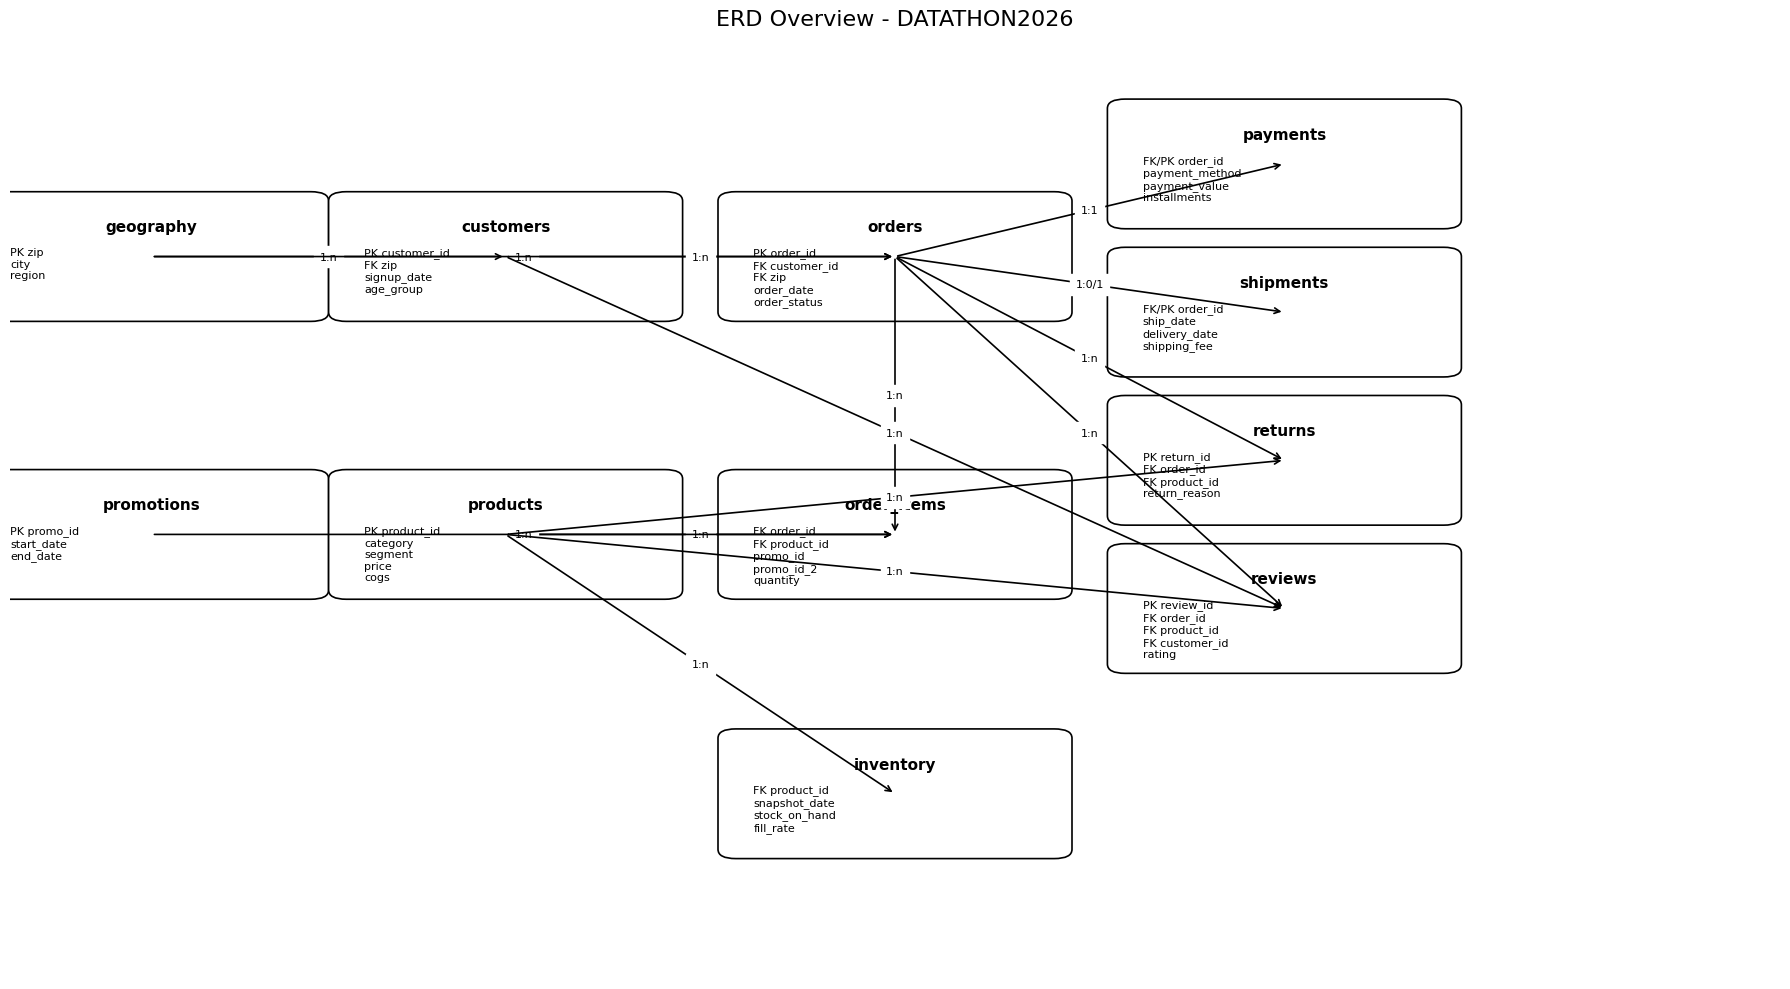

Saved: /home/habi/study/hau/university/DATATHON2026/reports/data_audit/erd_overview.png


In [11]:
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

node_positions = {
    "geography": (0.08, 0.78),
    "customers": (0.28, 0.78),
    "promotions": (0.08, 0.48),
    "products": (0.28, 0.48),
    "orders": (0.50, 0.78),
    "order_items": (0.50, 0.48),
    "payments": (0.72, 0.88),
    "shipments": (0.72, 0.72),
    "returns": (0.72, 0.56),
    "reviews": (0.72, 0.40),
    "inventory": (0.50, 0.20),
}

node_fields = {
    "geography": ["PK zip", "city", "region"],
    "customers": ["PK customer_id", "FK zip", "signup_date", "age_group"],
    "promotions": ["PK promo_id", "start_date", "end_date"],
    "products": ["PK product_id", "category", "segment", "price", "cogs"],
    "orders": ["PK order_id", "FK customer_id", "FK zip", "order_date", "order_status"],
    "order_items": ["FK order_id", "FK product_id", "promo_id", "promo_id_2", "quantity"],
    "payments": ["FK/PK order_id", "payment_method", "payment_value", "installments"],
    "shipments": ["FK/PK order_id", "ship_date", "delivery_date", "shipping_fee"],
    "returns": ["PK return_id", "FK order_id", "FK product_id", "return_reason"],
    "reviews": ["PK review_id", "FK order_id", "FK product_id", "FK customer_id", "rating"],
    "inventory": ["FK product_id", "snapshot_date", "stock_on_hand", "fill_rate"],
}

def draw_entity(ax, center_xy, title, fields, width=0.18, height=0.12):
    x, y = center_xy
    left = x - width / 2
    bottom = y - height / 2

    box = FancyBboxPatch(
        (left, bottom),
        width,
        height,
        boxstyle="round,pad=0.01,rounding_size=0.01",
        linewidth=1.2,
        edgecolor="black",
        facecolor="white",
    )
    ax.add_patch(box)

    title_y = y + height / 2 - 0.02
    ax.text(
        x,
        title_y,
        title,
        ha="center",
        va="top",
        fontsize=11,
        fontweight="bold"
    )

    body_text = "\n".join(fields[:5])
    ax.text(
        left + 0.01,
        title_y - 0.03,
        body_text,
        ha="left",
        va="top",
        fontsize=8
    )


for node, pos in node_positions.items():
    draw_entity(ax, pos, node, node_fields[node])

edges = [
    ("geography", "customers", "1:n"),
    ("geography", "orders", "1:n"),
    ("customers", "orders", "1:n"),
    ("orders", "order_items", "1:n"),
    ("products", "order_items", "1:n"),
    ("promotions", "order_items", "1:n"),
    ("orders", "payments", "1:1"),
    ("orders", "shipments", "1:0/1"),
    ("orders", "returns", "1:n"),
    ("products", "returns", "1:n"),
    ("orders", "reviews", "1:n"),
    ("products", "reviews", "1:n"),
    ("customers", "reviews", "1:n"),
    ("products", "inventory", "1:n"),
]

for src, dst, label in edges:
    x1, y1 = node_positions[src]
    x2, y2 = node_positions[dst]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=1.2)
    )

    mid_x = (x1 + x2) / 2
    mid_y = (y1 + y2) / 2
    ax.text(mid_x, mid_y, label, fontsize=8, ha="center", va="center", backgroundcolor="white")

plt.title("ERD Overview - DATATHON2026", fontsize=16, pad=20)
plt.tight_layout()

erd_path = OUTPUT_DIR / "erd_overview.png"
plt.savefig(erd_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {erd_path}")